# B.生成设计信息

## b1. 生成函数摘要 

In [1]:
from openai import OpenAI
import time
import json
import random
import tiktoken

import os
from pydantic import BaseModel, ValidationError
from typing import List, Dict
from dataclasses import dataclass, field
import re
import json
import pandas as pd
import numpy as np

from dotenv import load_dotenv

from structure_analsis.java.java_import_analyzer import JavaImportAnalyzer
from structure_analsis.java.java_method_analyzer import JavaMethodAnalyzer



In [2]:
load_dotenv()
client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY"),
    base_url=os.getenv("OPENAI_BASE_URL")
    )


In [3]:
os.makedirs("../out", exist_ok=True)

project_root = "../data/aurora"
output_csv = "out/file_adj_matrix.csv"

file_analyzer = JavaImportAnalyzer()
file_analyzer.analyze_project(project_root, output_file=output_csv)

method_analyzer = JavaMethodAnalyzer()
method_analyzer.analyze_project(project_root, output_dir="../out")

邻接矩阵已写入: out/file_adj_matrix.csv
方法信息已写入: out\method.csv
方法调用邻接矩阵已写入: out\method_adj_matrix.csv


In [4]:
@dataclass
class Function:
    func_id: int 
    func_name: str
    func_desc: str
    func_file: str
    func_flow: str
    func_notf: str 
    func_code: str
    func_fullName: str 
    func_txt_vector: List[float] = field(default_factory=list)

In [5]:
# 从out/methods.csv读取函数信息
method_df = pd.read_csv("../out/method.csv")
functions = []

for index, row in method_df.iterrows():

    function_fullName = row["method_signature"]
    function_name = function_fullName.split("(")[0].split(".")[-1]
    func_file = function_fullName.split("(")[0].split(".")[-2]
    function = Function(
        func_id=row["ID"],
        func_name=function_name,
        func_desc=function_name,
        func_file=func_file,
        func_flow="",
        func_notf="",
        func_code=row["method_code"],
        func_fullName=function_fullName,
        func_txt_vector=[]
    )
    functions.append(function)


In [6]:
for i, function in enumerate(functions):
    function.func_id = i # 从0开始


In [7]:
# 打印前5个函数 
for function in functions[:5]:
    print(f"Function ID: {function.func_id}, file name: {function.func_file}, Name: {function.func_name}, Description: {function.func_desc}")
    print(f"Code Snippet:\n{function.func_code}\n")

Function ID: 0, file name: AuroraSpringbootApplication, Name: main, Description: main
Code Snippet:
    public static void main(String[] args) {\n        SpringApplication.run(AuroraSpringbootApplication.class, args);\n    }\n\n    @Bean\n    public RestTemplate restTemplate() {\n        return new RestTemplate();\n    }\n\n}\n

Function ID: 1, file name: AuroraSpringbootApplication, Name: restTemplate, Description: restTemplate
Code Snippet:
    public RestTemplate restTemplate() {\n        return new RestTemplate();\n    }\n\n}\n

Function ID: 2, file name: ExceptionLogAspect, Name: exceptionLogPointcut, Description: exceptionLogPointcut
Code Snippet:
    public void exceptionLogPointcut() {\n    }\n\n    @AfterThrowing(value = "exceptionLogPointcut()", throwing = "e")\n    public void saveExceptionLog(JoinPoint joinPoint, Exception e) {\n        RequestAttributes requestAttributes = RequestContextHolder.getRequestAttributes();\n        HttpServletRequest request = (HttpServletReques

In [8]:
# 从func_adj_matrix.csv导入矩阵func_adj_matrix，不要表头
func_adj_matrix = pd.read_csv('../out/method_adj_matrix.csv', header=None).to_numpy()
func_adj_matrix = func_adj_matrix[1:, 1:]
print(len(func_adj_matrix), len(func_adj_matrix[0]))

703 703


In [9]:
# 打印前5个函数 
for function in functions[:5]:
    print(f"Function ID: {function.func_id}, Name: {function.func_name}, Description: {function.func_desc}")
    print(f"Code Snippet:\n{function.func_code}\n")

Function ID: 0, Name: main, Description: main
Code Snippet:
    public static void main(String[] args) {\n        SpringApplication.run(AuroraSpringbootApplication.class, args);\n    }\n\n    @Bean\n    public RestTemplate restTemplate() {\n        return new RestTemplate();\n    }\n\n}\n

Function ID: 1, Name: restTemplate, Description: restTemplate
Code Snippet:
    public RestTemplate restTemplate() {\n        return new RestTemplate();\n    }\n\n}\n

Function ID: 2, Name: exceptionLogPointcut, Description: exceptionLogPointcut
Code Snippet:
    public void exceptionLogPointcut() {\n    }\n\n    @AfterThrowing(value = "exceptionLogPointcut()", throwing = "e")\n    public void saveExceptionLog(JoinPoint joinPoint, Exception e) {\n        RequestAttributes requestAttributes = RequestContextHolder.getRequestAttributes();\n        HttpServletRequest request = (HttpServletRequest) Objects.requireNonNull(requestAttributes).resolveReference(RequestAttributes.REFERENCE_REQUEST);\n        Ex

## b2. 生成文件摘要


In [10]:
@dataclass
class File:
    file_id: int
    file_name: str
    file_path: str
    file_code: str = ""
    file_desc: str = ""
    file_discode: str = ""
    func_list: List[Function] = field(default_factory=list)
    file_txt_vector: List[float] = field(default_factory=list)

In [11]:
def create_directory_summary(root_path):
    Files_summary = []
    num = 0
    for root, dirs, files in os.walk(root_path):
        for file in files:
            if file.endswith(('.java')):
                afile_path = os.path.join(root, file)
                relative_path = os.path.relpath(afile_path, root_path)  # 转换为相对路径
                file_path = relative_path.replace("\\", ".").replace(".java", "")
                file_name = file_path.split(".")[-1]
                with open(afile_path, 'r', encoding='utf-8') as f:
                        file_content = f.read()
                
                file_summary = File(
                    file_id=num,
                    file_name=file_name,
                    file_path=file_path,
                    file_code=file_content,
                    file_desc=file_name,
                    func_list=[],
                    file_txt_vector=[],
                    file_discode=""
                )
                print(file_summary.file_path+" "+file_summary.file_desc)
                Files_summary.append(file_summary)
                num += 1
    return Files_summary

files = create_directory_summary(project_root)

aurora-springboot.src.main.com.aurora.AuroraSpringbootApplication AuroraSpringbootApplication
aurora-springboot.src.main.com.aurora.annotation.AccessLimit AccessLimit
aurora-springboot.src.main.com.aurora.annotation.OptLog OptLog
aurora-springboot.src.main.com.aurora.aspect.ExceptionLogAspect ExceptionLogAspect
aurora-springboot.src.main.com.aurora.aspect.OperationLogAspect OperationLogAspect
aurora-springboot.src.main.com.aurora.config.AsyncConfig AsyncConfig
aurora-springboot.src.main.com.aurora.config.GlobalZoneConfig GlobalZoneConfig
aurora-springboot.src.main.com.aurora.config.Knife4jConfig Knife4jConfig
aurora-springboot.src.main.com.aurora.config.MybatisPlusConfig MybatisPlusConfig
aurora-springboot.src.main.com.aurora.config.RabbitMQConfig RabbitMQConfig
aurora-springboot.src.main.com.aurora.config.RedisConfig RedisConfig
aurora-springboot.src.main.com.aurora.config.WebMvcConfig WebMvcConfig
aurora-springboot.src.main.com.aurora.config.WebSecurityConfig WebSecurityConfig
aurora

In [12]:
# 将函数添加到对应的文件中
for function in functions:
    # 从函数名称中提取类名
    class_name = function.func_file
    # 查找对应的文件
    for file in files:
        if file.file_name == class_name:
            file.func_list.append(function)
            break

In [13]:
# 打印前5个文件及其函数

for file in files[:5]:
    print(f"File ID: {file.file_id}, Name: {file.file_name}, Path: {file.file_path}, Description: {file.file_desc}")
    for function in file.func_list[:5]:  # 只打印前5个函数
        print(f"  Function ID: {function.func_id}, Name: {function.func_name}, Description: {function.func_desc}")
    print("\n")

File ID: 0, Name: AuroraSpringbootApplication, Path: aurora-springboot.src.main.com.aurora.AuroraSpringbootApplication, Description: AuroraSpringbootApplication
  Function ID: 0, Name: main, Description: main
  Function ID: 1, Name: restTemplate, Description: restTemplate


File ID: 1, Name: AccessLimit, Path: aurora-springboot.src.main.com.aurora.annotation.AccessLimit, Description: AccessLimit


File ID: 2, Name: OptLog, Path: aurora-springboot.src.main.com.aurora.annotation.OptLog, Description: OptLog


File ID: 3, Name: ExceptionLogAspect, Path: aurora-springboot.src.main.com.aurora.aspect.ExceptionLogAspect, Description: ExceptionLogAspect
  Function ID: 2, Name: exceptionLogPointcut, Description: exceptionLogPointcut
  Function ID: 3, Name: saveExceptionLog, Description: saveExceptionLog


File ID: 4, Name: OperationLogAspect, Path: aurora-springboot.src.main.com.aurora.aspect.OperationLogAspect, Description: OperationLogAspect
  Function ID: 4, Name: operationLogPointCut, Descri

In [14]:
# 打印每个文件中的函数列表
for file in files:
    print(f"File ID: {file.file_id}, Name: {file.file_name}, Functions: {[f.func_name for f in file.func_list]}")

File ID: 0, Name: AuroraSpringbootApplication, Functions: ['main', 'restTemplate']
File ID: 1, Name: AccessLimit, Functions: []
File ID: 2, Name: OptLog, Functions: []
File ID: 3, Name: ExceptionLogAspect, Functions: ['exceptionLogPointcut', 'saveExceptionLog']
File ID: 4, Name: OperationLogAspect, Functions: ['operationLogPointCut', 'saveOperationLog']
File ID: 5, Name: AsyncConfig, Functions: ['taskExecutor']
File ID: 6, Name: GlobalZoneConfig, Functions: ['setGlobalZone']
File ID: 7, Name: Knife4jConfig, Functions: ['createRestApi', 'apiInfo']
File ID: 8, Name: MybatisPlusConfig, Functions: ['mybatisPlusInterceptor']
File ID: 9, Name: RabbitMQConfig, Functions: ['articleQueue', 'maxWellExchange', 'bindingArticleDirect', 'emailQueue', 'emailExchange', 'bindingEmailDirect', 'subscribeQueue', 'subscribeExchange', 'bindingSubscribeDirect']
File ID: 10, Name: RedisConfig, Functions: ['redisTemplate']
File ID: 11, Name: WebMvcConfig, Functions: ['addCorsMappings', 'addInterceptors']
File 

## 将文件层聚类

### 计算文件之间的desc文本相似度，生成desc文本相似度矩阵

model:SENTENCE-bert
距离：余弦相似度

In [15]:
from sentence_transformers import SentenceTransformer
from dataclasses import dataclass
from typing import List
import numpy as np
import torch

In [16]:
class file_Cluster:
    cluster_id: int
    cluster_desc: str
    cluster_file_list: List[File]

    def __init__(self, cluster_id, cluster_desc, cluster_file_list):
        self.cluster_id = cluster_id
        self.cluster_desc = cluster_desc
        self.cluster_file_list = cluster_file_list

In [17]:
# 计算file之间的文本相似度
model = SentenceTransformer('all-mpnet-base-v2')

for file in files:
    # 计算文件的文本向量
    file.file_txt_vector = model.encode(file.file_desc).tolist()

In [18]:
# 得到文本相似度矩阵
def compute_similarity_matrix(files):
    # 提取文件向量
    txt_vectors = [file.file_txt_vector for file in files]
    normalized_vectors = txt_vectors / np.linalg.norm(txt_vectors, axis=1, keepdims=True)
    # 计算相似度矩阵
    similarity_matrix = np.dot(normalized_vectors, np.transpose(normalized_vectors))
    # 将相似度矩阵的值设置为0-1之间
    similarity_matrix = (similarity_matrix + 1) / 2
    return similarity_matrix

In [19]:
def _extract_identifiers(code: str):
    # 提取 Java/标识符 (字母或下划线开头)
    return set(re.findall(r'[A-Za-z_][A-Za-z0-9_]*', code))

# 计算链接矩阵 
def compute_link_matrix(files):
    link_matrix = np.zeros((len(files), len(files)))
    id_sets = {f.file_id: _extract_identifiers(f.file_code) for f in files}
    for file in files:
        name = file.file_name
        for other_file in files:
            if file.file_id == other_file.file_id:
                continue
            if (name in id_sets[other_file.file_id]) or (name == other_file.file_name):
                link_matrix[file.file_id][other_file.file_id] = 1
                link_matrix[other_file.file_id][file.file_id] = 1
    return link_matrix

In [20]:
similarity_matrix = compute_similarity_matrix(files)
link_matrix = compute_link_matrix(files)
# 统计link_matrix的非零值数量
non_zero_count = np.count_nonzero(link_matrix)
print(f"Number of non-zero values in the link matrix: {non_zero_count}")
# 计算最终的权重矩阵
weight_matrix = similarity_matrix + link_matrix

Number of non-zero values in the link matrix: 1878


### 利用weight矩阵聚类
方法：Leiden算法


文件聚类中社区规模差异可能很大。标准模块度倾向于生成相似大小的社区（分辨率限制问题），而CPM通过调整γ能更好地捕捉小社区，这对代码文件聚类很重要（比如某些功能由少数文件实现）




In [21]:
import numpy as np
import igraph as ig
import leidenalg as la
from collections import defaultdict
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
import matplotlib.pyplot as plt

In [22]:
def merge_tiny_clusters(labels, W, min_size=2, min_accept_sim=0.0, penalize_large=True, max_passes=5):
    """
    后处理：迭代把规模 < min_size 的簇并入最相似簇。
    参数:
        min_accept_sim: 若最高平均相似度仍低于该值则放弃合并
        penalize_large: 是否对巨大目标簇做轻量惩罚，避免全部吸入同一大簇
        max_passes: 最多迭代轮次
    """
    labels = np.array(labels)
    n_pass = 0
    changed_any = True
    while changed_any and n_pass < max_passes:
        changed_any = False
        n_pass += 1
        uniq = np.unique(labels)
        for c in uniq:
            idx = np.where(labels == c)[0]
            if idx.size >= min_size:
                continue
            best_target, best_score = None, -1.0
            for d in np.unique(labels):
                if d == c:
                    continue
                jdx = np.where(labels == d)[0]
                if jdx.size == 0:
                    continue
                score = W[np.ix_(idx, jdx)].mean()
                if penalize_large:
                    score = score / (1.0 + np.log1p(jdx.size))  # 轻度规模惩罚
                if score > best_score:
                    best_score, best_target = score, d
            if best_target is not None and best_score >= min_accept_sim:
                print(f" Merging tiny cluster {c} (size {idx.size}) into {best_target} (sim={best_score:.4f}) ")
                labels[idx] = best_target
                changed_any = True
        # 可提前结束：若本轮无变化
    return labels


def symmetrize_zero_diag(M):
    M = np.asarray(M, dtype=float)
    M = (M + M.T) / 2.0
    np.fill_diagonal(M, 0.0)
    M[M < 0] = 0.0
    return M

def normalize_01(M, eps=1e-12):
    M = symmetrize_zero_diag(M)
    mmin, mmax = M.min(), M.max()
    if mmax - mmin < eps:
        return np.zeros_like(M)
    M = (M - mmin) / (mmax - mmin)
    np.fill_diagonal(M, 0.0)
    return M

def fuse_weights(A, S, a=0.5):
    A_ = normalize_01(A)
    S_ = normalize_01(S)
    W = a * S_ + (1 - a) * A_
    return symmetrize_zero_diag(W)

def sparsify_knn(W, k=None):
    """
    kNN 稀疏化：每行仅保留 top-k 边；返回对称矩阵（取 max 保留）。
    k=None 表示不启用。
    """
    if k is None or k <= 0:
        return symmetrize_zero_diag(W)
    n = W.shape[0]
    W_keep = np.zeros_like(W)
    for i in range(n):
        row = W[i]
        # 排除对角线
        idx = np.argpartition(-row, min(k, n-1))[:min(k, n-1)]
        idx = idx[idx != i]
        W_keep[i, idx] = row[idx]
    # 对称化：保留两者中的较大者
    W_sym = np.maximum(W_keep, W_keep.T)
    np.fill_diagonal(W_sym, 0.0)
    return W_sym

def sparsify_threshold(W, tau=None):
    """
    按阈值稀疏化：权重 < tau 的边置 0。tau=None 表示不启用。
    """
    if tau is None or tau <= 0:
        return symmetrize_zero_diag(W)
    W2 = W.copy()
    W2[W2 < tau] = 0.0
    return symmetrize_zero_diag(W2)

def build_igraph_from_W(W):
    W = symmetrize_zero_diag(W)
    return ig.Graph.Weighted_Adjacency(W.tolist(), mode=ig.ADJ_UNDIRECTED, attr='weight', loops=False)

def run_leiden(W, gamma, seed=0, objective="CPM", n_iterations=-1):
    G = build_igraph_from_W(W)
    if objective.upper() == "CPM":
        part = la.find_partition(
            G, la.CPMVertexPartition,
            weights='weight',
            resolution_parameter=gamma,
            seed=seed,
            n_iterations=n_iterations
        )
    elif objective.upper() in ("RB", "RBCONFIGURATION", "RBCONFIG"):
        part = la.find_partition(
            G, la.RBConfigurationVertexPartition,
            weights='weight',
            resolution_parameter=gamma,
            seed=seed,
            n_iterations=n_iterations
        )
    else:
        raise ValueError("objective must be 'CPM' or 'RBConfiguration'")
    labels = np.array(part.membership, dtype=int)
    quality = float(part.quality())
    return labels, quality

def cluster_size_stats(labels):
    labels = np.asarray(labels)
    vals, counts = np.unique(labels, return_counts=True)
    sizes = counts
    n = labels.size
    n_clusters = len(sizes)
    singleton_frac = (sizes == 1).sum() / n_clusters if n_clusters > 0 else 0.0
    tiny_frac = (sizes <= 2).sum() / n_clusters if n_clusters > 0 else 0.0
    cv = (np.std(sizes) / (np.mean(sizes) + 1e-12)) if n_clusters > 0 else 0.0
    return dict(n_clusters=n_clusters, sizes=sizes, singleton_frac=singleton_frac, tiny_frac=tiny_frac, size_cv=cv)

def cluster_intra_inter_separation(W, labels):
    """
    返回整体分离度：平均(簇内均值 - 簇外均值)，按簇大小加权。
    值越大越好；范围大致在 [-1,1]。
    """
    labels = np.asarray(labels)
    n = len(labels)
    total = 0.0
    weight_sum = 0.0
    for c in np.unique(labels):
        idx = np.where(labels == c)[0]
        m = idx.size
        if m <= 1:
            continue
        comp = np.setdiff1d(np.arange(n), idx, assume_unique=True)
        sub = W[np.ix_(idx, idx)]
        intra = sub.sum() / (m * (m - 1))  # 平均非对角簇内权重（双计数/分母匹配）
        inter = 0.0
        if comp.size > 0:
            inter = W[np.ix_(idx, comp)].mean()
        total += (intra - inter) * m
        weight_sum += m
    return float(total / (weight_sum + 1e-12)) if weight_sum > 0 else 0.0

def cluster_density_std(W, labels):
    """
    计算各簇平均内部密度的标准差（越小说明“均衡”）。
    """
    labels = np.asarray(labels)
    densities = []
    for c in np.unique(labels):
        idx = np.where(labels == c)[0]
        m = idx.size
        if m <= 1:
            continue
        sub = W[np.ix_(idx, idx)]
        density = sub.sum() / (m * (m - 1))
        densities.append(density)
    return float(np.std(densities)) if densities else float('inf')

def coassociation_matrix(partitions):
    """
    共识矩阵：C[i,j] = 在多少比例的划分中 i 和 j 同簇。
    注意：O(n^2) 内存，对大图谨慎使用。
    """
    n = len(partitions[0])
    C = np.zeros((n, n), dtype=np.float32)
    for labels in partitions:
        labels = np.asarray(labels)
        for c in np.unique(labels):
            idx = np.where(labels == c)[0]
            if idx.size == 0:
                continue
            C[np.ix_(idx, idx)] += 1.0
    C /= len(partitions)
    np.fill_diagonal(C, 1.0)
    return C

def consensus_labels_from_coassoc(C, tau=0.6, gamma=0.1, seed=0):
    Wc = C.copy()
    Wc[Wc < tau] = 0.0
    np.fill_diagonal(Wc, 0.0)
    labels, _ = run_leiden(Wc, gamma=gamma, seed=seed, objective="CPM")
    return labels

def pairwise_mean_ari(partitions):
    if len(partitions) <= 1:
        return 1.0
    ARIs = []
    for i in range(len(partitions)):
        for j in range(i+1, len(partitions)):
            ARIs.append(adjusted_rand_score(partitions[i], partitions[j]))
    return float(np.mean(ARIs))

def safe_silhouette_from_similarity(W, labels, use_silhouette=False, sample_size=None, rng=42):
    """
    可选计算 silhouette（使用距离 1-W）。默认关闭以避免误用非度量距离。
    """
    if not use_silhouette:
        return None
    n = W.shape[0]
    dist = 1.0 - np.clip(W, 0.0, 1.0)
    np.fill_diagonal(dist, 0.0)
    labels = np.asarray(labels)
    # 至少要有 2 个簇且每个簇 >= 2
    uniq, counts = np.unique(labels, return_counts=True)
    if uniq.size < 2 or np.any(counts < 2):
        return None
    if sample_size is not None and sample_size < n:
        rng = np.random.default_rng(rng)
        idx = rng.choice(n, size=sample_size, replace=False)
        dist = dist[np.ix_(idx, idx)]
        labels = labels[idx]
    try:
        return float(silhouette_score(dist, labels, metric="precomputed"))
    except Exception:
        return None

# ------------ 主函数 ------------
def find_best_resolution(
    files,
    a=0.5,
    n_points=30,
    gamma_min=1e-1,
    gamma_max=1.0,
    seeds_per_gamma=8,
    min_clusters=2,
    max_clusters_ratio=0.2,   # 最多簇数不超过 n 的 20%
    min_cluster_size=2,       # 小簇阈值
    use_knn=True,
    knn_k=20,
    use_threshold=False,
    threshold_tau=0.0,
    use_silhouette=False,     # 默认关闭 silhouette
    silhouette_sample_size=None,
    objective="CPM",
    plot=True,
    consensus_tau=0.6,
    consensus_gamma=0.1,
    random_state=2025
):
    """
    返回:
    - best_gamma: 最优分辨率
    - best_labels: 最优 γ 的“共识”聚类标签（多次运行整合）
    - results: 每个 γ 的统计与指标
    说明：
    - 避免大量小簇：通过 kNN/阈值稀疏、对小簇比例与规模不均衡施加惩罚、限定簇数量范围，以及强调稳定性指标（ARI）。
    """
    rng = np.random.default_rng(random_state)

    # 1) 计算并融合权重矩阵
    # 你已有的函数：compute_similarity_matrix / compute_link_matrix
    S = compute_similarity_matrix(files)   # 语义相似度（任意尺度）
    A = compute_link_matrix(files)         # 依赖邻接（任意尺度）
    W = fuse_weights(A, S, a=a)

    # 2) 稀疏化（推荐至少启用一种）
    if use_knn:
        W = sparsify_knn(W, k=knn_k)
    if use_threshold and threshold_tau > 0:
        W = sparsify_threshold(W, tau=threshold_tau)
    np.fill_diagonal(W, 0.0)

    n = W.shape[0]
    max_clusters = max(2, int(max_clusters_ratio * n))

    # 3) 准备 γ 网格（对数均匀）
    gamma_values = np.logspace(np.log10(gamma_min), np.log10(gamma_max), num=n_points)

    # 4) 扫描 γ：多次运行 + 指标统计
    all_results = []
    for gamma in gamma_values:
        partitions = []
        qualities = []
        size_stats_list = []
        separations = []
        density_stds = []
        sils = []

        for s in range(seeds_per_gamma):
            seed = int(rng.integers(0, 1_000_000))
            labels, quality = run_leiden(W, gamma=gamma, seed=seed, objective=objective)
            partitions.append(labels)
            qualities.append(quality)

            # 规模与小簇统计
            ss = cluster_size_stats(labels)
            size_stats_list.append(ss)

            # 分离度与密度均衡度
            separations.append(cluster_intra_inter_separation(W, labels))
            density_stds.append(cluster_density_std(W, labels))

            # 可选 silhouette
            sil_val = safe_silhouette_from_similarity(
                W, labels, use_silhouette=use_silhouette,
                sample_size=silhouette_sample_size, rng=seed
            )
            if sil_val is not None:
                sils.append(sil_val)

        # 稳定性（平均 ARI）
        mean_ARI = pairwise_mean_ari(partitions)

        # 聚合统计
        mean_quality = float(np.mean(qualities))
        mean_sep = float(np.mean(separations))
        mean_density_std = float(np.mean([d for d in density_stds if np.isfinite(d)]) if any(np.isfinite(density_stds)) else np.inf)
        mean_sil = float(np.mean(sils)) if sils else None

        # 将种子层面的规模统计聚合（取均值）
        n_clusters_list = [ss["n_clusters"] for ss in size_stats_list]
        singleton_fracs = [ss["singleton_frac"] for ss in size_stats_list]
        tiny_fracs = [ss["tiny_frac"] for ss in size_stats_list]
        size_cvs = [ss["size_cv"] for ss in size_stats_list]

        agg = dict(
            gamma=float(gamma),
            mean_ARI=mean_ARI,
            mean_quality=mean_quality,
            mean_sep=mean_sep,
            mean_density_std=mean_density_std,
            mean_sil=mean_sil,
            mean_n_clusters=float(np.mean(n_clusters_list)),
            p50_n_clusters=float(np.median(n_clusters_list)),
            mean_singleton_frac=float(np.mean(singleton_fracs)),
            mean_tiny_frac=float(np.mean(tiny_fracs)),
            mean_size_cv=float(np.mean(size_cvs)),
            partitions=partitions  # 用于后续共识
        )
        all_results.append(agg)

    # 5) 组合评分（越大越好）
    #   - 强调稳定性 (ARI) 与分离度 (sep)
    #   - 惩罚小簇比例、簇数过多、规模不均衡
    #   - silhouette 若开启则纳入加分
    def minmax(xs):
        xs = np.array(xs, dtype=float)
        if np.all(~np.isfinite(xs)):
            return np.zeros_like(xs), 0.0, 1.0
        xs[~np.isfinite(xs)] = np.nan
        vmin = np.nanmin(xs)
        vmax = np.nanmax(xs)
        if not np.isfinite(vmin) or not np.isfinite(vmax) or abs(vmax - vmin) < 1e-12:
            return np.zeros_like(xs), vmin, vmax
        return (xs - vmin) / (vmax - vmin), vmin, vmax

    ARIs = [r["mean_ARI"] for r in all_results]
    SEPs = [r["mean_sep"] for r in all_results]
    SILs = [(-1 if r["mean_sil"] is None else r["mean_sil"]) for r in all_results]
    NCLS = [r["mean_n_clusters"] for r in all_results]
    SINGLE = [r["mean_singleton_frac"] for r in all_results]
    TINY = [r["mean_tiny_frac"] for r in all_results]
    SIZECV = [r["mean_size_cv"] for r in all_results]
    DSTD = [r["mean_density_std"] for r in all_results]

    n_ARIs, _, _ = minmax(ARIs)
    n_SEPs, _, _ = minmax(SEPs)
    n_SILs, _, _ = minmax(SILs) if any(s >= -1 for s in SILs) and use_silhouette else (np.zeros_like(ARIs), 0, 1)

    # 簇数惩罚：超过 max_clusters 或小于 min_clusters 都扣分
    over_penalty = np.clip((np.array(NCLS) - max_clusters) / max(1, max_clusters), 0, 1)
    under_penalty = np.clip((min_clusters - np.array(NCLS)) / max(1, min_clusters), 0, 1)

    # 小簇惩罚（对单点和极小簇）
    small_penalty = 0.5 * np.array(SINGLE) + 0.5 * np.array(TINY)

    # 规模不均衡惩罚：对 size CV 做软压制（>1 显著不均衡）
    sizecv_penalty = np.clip((np.array(SIZECV) - 1.0) / 1.0, 0, 1)

    # 密度标准差惩罚：归一化后取负向
    # 当存在 inf（说明多为单点簇），直接给高惩罚
    dstd_arr = np.array(DSTD, dtype=float)
    dstd_arr[~np.isfinite(dstd_arr)] = np.nanmax(dstd_arr[np.isfinite(dstd_arr)]) if np.any(np.isfinite(dstd_arr)) else 1.0
    n_DSTD, _, _ = minmax(dstd_arr)
    dstd_penalty = n_DSTD

    # 权重可按需调整
    w_stab = 0.45   # 稳定性
    w_sep  = 0.45   # 分离度
    w_sil  = 0   # 可选 silhouette
    w_pen_small = 0.40
    w_pen_over  = 0.20
    w_pen_under = 0.10
    w_pen_sizecv= 0.20
    w_pen_dstd  = 0.15

    combined_scores = (
        w_stab * n_ARIs
        + w_sep * n_SEPs
        + (w_sil * n_SILs if use_silhouette else 0)
        - (w_pen_small * small_penalty
           + w_pen_over * over_penalty
           + w_pen_under * under_penalty
           + w_pen_sizecv * sizecv_penalty
           + w_pen_dstd * dstd_penalty)
    )

    for i, r in enumerate(all_results):
        r["combined_score"] = float(combined_scores[i])

    # 6) 选出 best γ，并用“共识矩阵”产生最终标签（更稳健）
    best_idx = int(np.argmax(combined_scores))
    best_gamma = float(all_results[best_idx]["gamma"])
    best_partitions = all_results[best_idx]["partitions"]


    C = coassociation_matrix(best_partitions)
    best_labels = consensus_labels_from_coassoc(
        C, tau=consensus_tau, gamma=consensus_gamma,
        seed=int(rng.integers(0, 1_000_000))
    )
    print(f"Best gamma: {best_gamma}, #Clusters: {len(np.unique(best_labels))}")
    best_labels = merge_tiny_clusters(best_labels, W, min_size=2, min_accept_sim=0.0, penalize_large=True, max_passes=5)
    print(f"After merging tiny clusters, #Clusters: {len(np.unique(best_labels))}")
    # 7) 可视化
    if plot:
        gammas = [r["gamma"] for r in all_results]
        fig, axes = plt.subplots(2, 3, figsize=(16, 9))
        # 稳定性
        axes[0,0].plot(gammas, ARIs, 'bo-')
        axes[0,0].axvline(best_gamma, color='r', ls='--')
        axes[0,0].set_xscale('log'); axes[0,0].set_title('Mean ARI (stability)'); axes[0,0].set_xlabel('gamma'); axes[0,0].grid(True, which='both', ls='--')

        # 分离度
        axes[0,1].plot(gammas, SEPs, 'go-')
        axes[0,1].axvline(best_gamma, color='r', ls='--')
        axes[0,1].set_xscale('log'); axes[0,1].set_title('Intra-Inter Separation'); axes[0,1].set_xlabel('gamma'); axes[0,1].grid(True, which='both', ls='--')

        # 簇数
        axes[0,2].plot(gammas, NCLS, 'mo-')
        axes[0,2].axhline(max_clusters, color='k', ls=':', label='max_clusters')
        axes[0,2].axhline(min_clusters, color='k', ls='--', label='min_clusters')
        axes[0,2].axvline(best_gamma, color='r', ls='--')
        axes[0,2].set_xscale('log'); axes[0,2].set_title('Mean #Clusters'); axes[0,2].set_xlabel('gamma'); axes[0,2].legend(); axes[0,2].grid(True, which='both', ls='--')

        # 小簇与单点
        axes[1,0].plot(gammas, SINGLE, 'co-', label='singleton_frac')
        axes[1,0].plot(gammas, TINY, 'yo-', label='tiny_frac (<=2)')
        axes[1,0].axvline(best_gamma, color='r', ls='--')
        axes[1,0].set_xscale('log'); axes[1,0].set_title('Small-cluster Fractions'); axes[1,0].set_xlabel('gamma'); axes[1,0].legend(); axes[1,0].grid(True, which='both', ls='--')

        # 综合评分
        axes[1,1].plot(gammas, combined_scores, 'ko-')
        axes[1,1].axvline(best_gamma, color='r', ls='--')
        axes[1,1].set_xscale('log'); axes[1,1].set_title('Combined Score'); axes[1,1].set_xlabel('gamma'); axes[1,1].grid(True, which='both', ls='--')

        # 可选 silhouette
        if use_silhouette and any(s is not None for s in SILs):
            axes[1,2].plot(gammas, [np.nan if s == -1 else s for s in SILs], 'rs-')
            axes[1,2].axvline(best_gamma, color='r', ls='--')
            axes[1,2].set_xscale('log'); axes[1,2].set_title('Mean Silhouette (optional)'); axes[1,2].set_xlabel('gamma'); axes[1,2].grid(True, which='both', ls='--')
        else:
            axes[1,2].axis('off')

        plt.tight_layout()
        plt.show()

    return best_gamma, best_labels, all_results

Best gamma: 0.25223334097887234, #Clusters: 47
 Merging tiny cluster 39 (size 1) into 16 (sim=0.0698) 
 Merging tiny cluster 40 (size 1) into 46 (sim=0.1918) 
 Merging tiny cluster 41 (size 1) into 45 (sim=0.4912) 
 Merging tiny cluster 42 (size 1) into 35 (sim=0.0795) 
 Merging tiny cluster 43 (size 1) into 28 (sim=0.0654) 
 Merging tiny cluster 44 (size 1) into 27 (sim=0.2322) 
After merging tiny clusters, #Clusters: 41


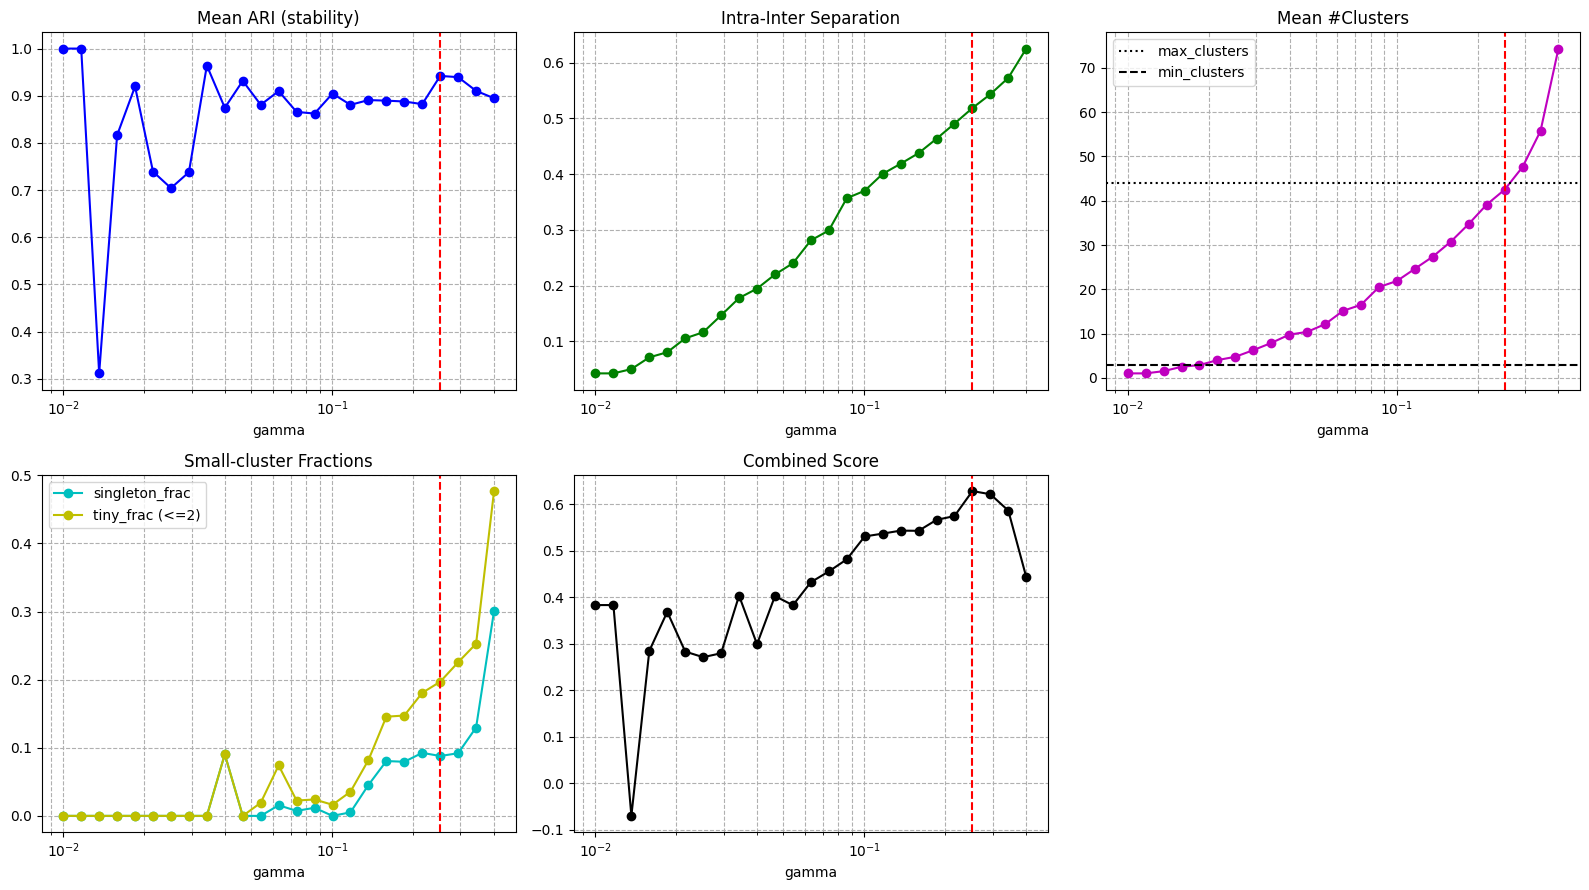

最佳 γ = 0.25223334097887234
簇数 = 41


In [23]:
best_gamma, best_labels, results = find_best_resolution(
    files,
    a=0.5,                 # 更看重语义时调高
    n_points=25,
    gamma_min=0.01, gamma_max=0.4,  # 收窄范围减少过度切分
    seeds_per_gamma=8,
    use_knn=True, knn_k=20,         # 建议开启
    use_threshold=False, threshold_tau=0.0,
    min_clusters=3, max_clusters_ratio=0.15,
    min_cluster_size=3,
    use_silhouette=False,           # 默认关，避免误导
    plot=True
)
print("最佳 γ =", best_gamma)
print("簇数 =", len(np.unique(best_labels)))

In [24]:
print(best_labels)

[ 7 16  8  5  8 34 36 46 23 17 23 23 30 24 24 17 27 19 24 17 45  3 21 28
 31 28  1  7  5 12  6  5 13  3 14  9  8  2  2 15  0 10 11 16  4 35  1 25
 12  6  5 13  3 14  9  8  2  2 15  0  0  0 10 11 26 32  4  0 23  1  6 18
 18  3  8 25  2  0 20 33 11 18  4 36  5  8 33  5 27 30 19 19 19 19 33 30
 35 19 38  7 35  1 25 12  6 20  5 13 14  3  9  8  2  2 15  0  0  0 10 11
 26 32  4  0 23  7 28  1  1  1  1  1 20  1  7  7  7 12 12 12  6  6  6 28
  5 13 13  3 14 15 31  9  8 14  2  2  2  2 17 17  6 15  0  0 21 21 10 10
 11 11  1 26 16 16 27  4 16  9  4  0  7 22  1  1  1 12  6 10 22 22 13  9
 14  3  3  3  3  9 16  2  2  2 17 15 19 22 22 22 10 11  4  4  4 16  7  3
 45 34  3  1 25  7 12  6  5 13 14  3  9  8  2  2 37 15  0  0  0 10 11 27
 26 16  4  0  1 25  7 12  6  5 13 14  3  9  8  2  2 37 15  0  0  0 10 11
 27 26 16 32  4  0  1 20 21 18  1 20 21 18 21 18 20 24 20  1 24 17 31 29
 29 28  5 18 29 46  3 38  3 29  4]


In [25]:
def save_to_file_cluster(files, best_labels):
    file_clusters = {}
    # 将index和label对应起来
    for i, file in enumerate(files):
        if best_labels[i] not in file_clusters:
            file_clusters[best_labels[i]] = file_Cluster(best_labels[i], "", [])
        file_clusters[best_labels[i]].cluster_file_list.append(file)
    return file_clusters.values()


In [26]:
clusters = save_to_file_cluster(files, best_labels)

In [27]:
# 打印clusters
for c in clusters:
    print(f"Cluster ID: {c.cluster_id}, {len(c.cluster_file_list)} Files: {[file.file_name for file in c.cluster_file_list]}")

Cluster ID: 7, 11 Files: ['AuroraSpringbootApplication', 'AuroraInfoController', 'AuroraListener', 'AboutDTO', 'AuroraAdminInfoDTO', 'AuroraBackInfoDTO', 'AuroraHomeInfoDTO', 'WebsiteConfigDTO', 'WebsiteConfigVO', 'AuroraInfoService', 'AuroraInfoServiceImpl']
Cluster ID: 16, 9 Files: ['AccessLimit', 'UserAuthController', 'UserAdminDTO', 'UserAreaDTO', 'UserLogoutStatusDTO', 'PasswordVO', 'UserVO', 'UserAuthService', 'UserAuthServiceImpl']
Cluster ID: 8, 10 Files: ['OptLog', 'OperationLogAspect', 'OperationLogController', 'OperationLog', 'LoginTypeEnum', 'OperationLogEvent', 'OperationLogMapper', 'OperationLogDTO', 'OperationLogService', 'OperationLogServiceImpl']
Cluster ID: 5, 11 Files: ['ExceptionLogAspect', 'BizExceptionController', 'ExceptionLogController', 'ExceptionLog', 'ExceptionLogEvent', 'TaskException', 'ExceptionLogMapper', 'ExceptionLogDTO', 'ExceptionLogService', 'ExceptionLogServiceImpl', 'ExceptionUtil']
Cluster ID: 34, 2 Files: ['AsyncConfig', 'QuartzDisallowConcurrent

In [28]:
print("len(clusters):", len(clusters))

len(clusters): 41


## 将文件层展开到函数层


In [29]:
class method_Cluster:
    cluster_id: int
    cluster_desc: str
    cluster_func_list: List[Function]

    def __init__(self, cluster_id, cluster_desc, cluster_func_list):
        self.cluster_id = cluster_id
        self.cluster_desc = cluster_desc
        self.cluster_func_list = cluster_func_list

## 将函数层聚类，得到函数簇

In [30]:
class Feature:
    cluster_id: int
    feature_id: int
    feature_desc: str
    feature_flow: str = ""
    feature_notf: str = ""
    feature_func_list: List[Function]

    def __init__(self, cluster_id,feature_id, feature_desc, feature_func_list):
        self.cluster_id = cluster_id
        self.feature_id = feature_id
        self.feature_desc = feature_desc
        self.feature_func_list = feature_func_list

In [31]:
method_clusters = []
# 将clusters展开到函数层
for cluster in clusters:
    list = []
    for file in cluster.cluster_file_list:
        for function in file.func_list:
            # 将函数添加到聚类中
            function.func_txt_vector = model.encode(function.func_desc).tolist()
            list.append(function)
    method_cluster = method_Cluster(cluster.cluster_id, "", list)
    method_clusters.append(method_cluster)

# 打印每个聚类的函数列表
for method_cluster in method_clusters:
    print(f"Cluster ID: {method_cluster.cluster_id}, Functions: {[f.func_name for f in method_cluster.cluster_func_list]}")

Cluster ID: 7, Functions: ['main', 'restTemplate', 'report', 'getBlogHomeInfo', 'getBlogBackInfo', 'updateWebsiteConfig', 'getWebsiteConfig', 'getAbout', 'updateAbout', 'savePhotoAlbumCover', 'saveOperationLog', 'saveExceptionLog', 'report', 'getAuroraHomeInfo', 'getAuroraAdminInfo', 'updateWebsiteConfig', 'getWebsiteConfig', 'updateAbout', 'getAbout', 'report', 'getAuroraHomeInfo', 'getAuroraAdminInfo', 'updateWebsiteConfig', 'getWebsiteConfig', 'updateAbout', 'getAbout', 'listArticleRank']
Cluster ID: 16, Functions: ['sendCode', 'listUserAreas', 'listUsers', 'register', 'updatePassword', 'updateAdminPassword', 'logout', 'qqLogin', 'sendCode', 'listUserAreas', 'register', 'updatePassword', 'updateAdminPassword', 'listUsers', 'logout', 'qqLogin', 'sendCode', 'listUserAreas', 'register', 'updatePassword', 'updateAdminPassword', 'listUsers', 'logout', 'qqLogin', 'checkUser']
Cluster ID: 8, Functions: ['operationLogPointCut', 'saveOperationLog', 'listOperationLogs', 'deleteOperationLogs',

In [39]:
# 得到文本相似度矩阵
def compute_similarity_matrix(method_cluster):
    txt_vectors = [func.func_txt_vector for func in method_cluster.cluster_func_list]
    # 没有向量的情况
    if len(txt_vectors) == 0:
        return np.zeros((0, 0))

    # 把每个向量显式转为 numpy array（float），处理空或不同长度情况
    vecs = [np.asarray(v, dtype=float) for v in txt_vectors]
    lengths = [v.size for v in vecs]
    maxlen = max(lengths)

    # 若长度不一致，pad 短向量为 maxlen（也可选择抛错）
    if any(l != maxlen for l in lengths):
        vecs = [np.pad(v, (0, maxlen - v.size), mode='constant') if v.size < maxlen else v for v in vecs]

    X = np.vstack(vecs)  # shape (n, d)

    # 归一化：避免除以 0
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    Xn = X / norms

    similarity_matrix = np.dot(Xn, Xn.T)
    # 映射到 0-1
    similarity_matrix = (similarity_matrix + 1.0) / 2.0
    return similarity_matrix

In [40]:
def compute_link(method_cluster):
    link_matrix = np.zeros((len(method_cluster.cluster_func_list), len(method_cluster.cluster_func_list)))
    i=0 
    for function in method_cluster.cluster_func_list:
        j=0
        for other_function in method_cluster.cluster_func_list:
            if i == j:
                j += 1
                continue
            if func_adj_matrix[function.func_id][other_function.func_id] != 0:
                # 如果存在call和caller关系，设置邻接矩阵的对应位置为 1
                link_matrix[i][j] = 1
                link_matrix[j][i] = 1
            j += 1
        i += 1
    return link_matrix

In [41]:
import numpy as np
import igraph as ig
import leidenalg as la
from collections import defaultdict
from dataclasses import dataclass
from typing import List, Dict, Optional, Iterable, Any, Tuple

# 和文件层一样的调参方法

In [47]:
def symmetrize_zero_diag(M: np.ndarray) -> np.ndarray:
    M = np.asarray(M, dtype=float)
    if M.size == 0:
        return M  # 早期返回，保持空矩阵
    M = (M + M.T) / 2.0
    np.fill_diagonal(M, 0.0)
    M[M < 0] = 0.0
    return M

def normalize_01(M: np.ndarray, eps=1e-12) -> np.ndarray:
    M = symmetrize_zero_diag(M)
    if M.size == 0:
        return np.zeros_like(M)
    mmin, mmax = M.min(), M.max()
    if not np.isfinite(mmin) or not np.isfinite(mmax) or (mmax - mmin) < eps:
        return np.zeros_like(M)
    M = (M - mmin) / (mmax - mmin)
    np.fill_diagonal(M, 0.0)
    return M

def fuse_weights_func(S: np.ndarray, L: np.ndarray, a: float) -> np.ndarray:
    S_ = normalize_01(S)
    L_ = normalize_01(L)
    W = a * S_ + (1 - a) * L_
    return symmetrize_zero_diag(W)

def sparsify_knn(W: np.ndarray, k: Optional[int] = None) -> np.ndarray:
    if k is None or k <= 0:
        return symmetrize_zero_diag(W)
    n = W.shape[0]
    W_keep = np.zeros_like(W)
    for i in range(n):
        row = W[i]
        # top-k（排除自己）；注意 np.argpartition 的边界
        kk = min(k, n - 1)
        idx = np.argpartition(-row, kk)[:kk]
        idx = idx[idx != i]
        W_keep[i, idx] = row[idx]
    W_sym = np.maximum(W_keep, W_keep.T)
    np.fill_diagonal(W_sym, 0.0)
    return W_sym

def sparsify_threshold(W: np.ndarray, tau: Optional[float] = None) -> np.ndarray:
    if tau is None or tau <= 0:
        return symmetrize_zero_diag(W)
    W2 = W.copy()
    W2[W2 < tau] = 0.0
    return symmetrize_zero_diag(W2)

def build_graph(W: np.ndarray) -> ig.Graph:
    return ig.Graph.Weighted_Adjacency(W.tolist(), mode=ig.ADJ_UNDIRECTED, attr='weight', loops=False)

def run_leiden_on_W(W: np.ndarray, gamma: float, seed: int, objective: str = "CPM", n_iterations: int = -1) -> Tuple[np.ndarray, float]:
    G = build_graph(W)
    if objective.upper() == "CPM":
        part = la.find_partition(G, la.CPMVertexPartition, weights='weight', resolution_parameter=gamma, seed=seed, n_iterations=n_iterations)
    elif objective.upper() in ("RB", "RBCONFIGURATION", "RBCONFIG"):
        part = la.find_partition(G, la.RBConfigurationVertexPartition, weights='weight', resolution_parameter=gamma, seed=seed, n_iterations=n_iterations)
    else:
        raise ValueError("objective must be 'CPM' or 'RBConfiguration'")
    labels = np.array(part.membership, dtype=int)
    return labels, float(part.quality())

def cluster_size_stats(labels: np.ndarray) -> Dict[str, Any]:
    labels = np.asarray(labels)
    vals, counts = np.unique(labels, return_counts=True)
    sizes = counts
    n_clusters = len(sizes)
    singleton_frac = (sizes == 1).sum() / n_clusters if n_clusters > 0 else 0.0
    tiny_frac = (sizes <= 2).sum() / n_clusters if n_clusters > 0 else 0.0
    size_cv = (np.std(sizes) / (np.mean(sizes) + 1e-12)) if n_clusters > 0 else 0.0
    return dict(n_clusters=n_clusters, sizes=sizes, singleton_frac=singleton_frac, tiny_frac=tiny_frac, size_cv=size_cv)

def intra_inter_separation(W: np.ndarray, labels: np.ndarray) -> float:
    labels = np.asarray(labels)
    n = len(labels)
    total, wsum = 0.0, 0.0
    for c in np.unique(labels):
        idx = np.where(labels == c)[0]
        m = idx.size
        if m <= 1:
            continue
        comp = np.setdiff1d(np.arange(n), idx, assume_unique=True)
        sub = W[np.ix_(idx, idx)]
        intra = sub.sum() / (m * (m - 1))
        inter = W[np.ix_(idx, comp)].mean() if comp.size > 0 else 0.0
        total += (intra - inter) * m
        wsum += m
    return float(total / (wsum + 1e-12)) if wsum > 0 else 0.0

def cluster_density_std(W: np.ndarray, labels: np.ndarray) -> float:
    labels = np.asarray(labels)
    densities = []
    for c in np.unique(labels):
        idx = np.where(labels == c)[0]
        m = idx.size
        if m <= 1:
            continue
        sub = W[np.ix_(idx, idx)]
        dens = sub.sum() / (m * (m - 1))
        densities.append(dens)
    return float(np.std(densities)) if densities else float("inf")

def coassociation_matrix(partitions: List[np.ndarray]) -> np.ndarray:
    n = len(partitions[0])
    C = np.zeros((n, n), dtype=np.float32)
    for labels in partitions:
        labels = np.asarray(labels)
        for c in np.unique(labels):
            idx = np.where(labels == c)[0]
            if idx.size == 0:
                continue
            C[np.ix_(idx, idx)] += 1.0
    C /= len(partitions)
    np.fill_diagonal(C, 1.0)
    return C

def leiden_on_consensus(C: np.ndarray, tau: float = 0.6, gamma: float = 0.1, seed: int = 0) -> np.ndarray:
    Wc = C.copy()
    Wc[Wc < tau] = 0.0
    np.fill_diagonal(Wc, 0.0)
    labels, _ = run_leiden_on_W(Wc, gamma=gamma, seed=seed, objective="CPM")
    return labels

def pairwise_mean_ari(partitions: List[np.ndarray]) -> float:
    if len(partitions) <= 1:
        return 1.0
    ARIs = []
    for i in range(len(partitions)):
        for j in range(i + 1, len(partitions)):
            ARIs.append(adjusted_rand_score(partitions[i], partitions[j]))
    return float(np.mean(ARIs)) if ARIs else 1.0

def safe_silhouette_from_similarity(W: np.ndarray, labels: np.ndarray, use_silhouette: bool = False, sample_size: Optional[int] = None, rng: int = 42) -> Optional[float]:
    if not use_silhouette:
        return None
    dist = 1.0 - np.clip(W, 0.0, 1.0)
    np.fill_diagonal(dist, 0.0)
    labels = np.asarray(labels)
    uniq, counts = np.unique(labels, return_counts=True)
    if uniq.size < 2 or np.any(counts < 2):
        return None
    if sample_size is not None and sample_size < len(labels):
        rnd = np.random.default_rng(rng)
        idx = rnd.choice(len(labels), size=sample_size, replace=False)
        dist = dist[np.ix_(idx, idx)]
        labels = labels[idx]
    try:
        return float(silhouette_score(dist, labels, metric="precomputed"))
    except Exception:
        return None

def _minmax(xs: List[float]) -> Tuple[np.ndarray, float, float]:
    arr = np.array(xs, dtype=float)
    arr[~np.isfinite(arr)] = np.nan
    if np.all(np.isnan(arr)):
        return np.zeros_like(arr), 0.0, 1.0
    vmin = np.nanmin(arr)
    vmax = np.nanmax(arr)
    if not np.isfinite(vmin) or not np.isfinite(vmax) or abs(vmax - vmin) < 1e-12:
        return np.zeros_like(arr), vmin, vmax
    return (arr - vmin) / (vmax - vmin), vmin, vmax

@dataclass
class ModuleBestResult:
    module_cluster_id: Any
    m_funcs: int
    best_gamma: float
    best_labels: np.ndarray
    combined_score: float
    mean_ARI: float
    mean_sep: float
    mean_sil: Optional[float]
    mean_n_clusters: float
    mean_singleton_frac: float
    mean_tiny_frac: float
    mean_size_cv: float
    notes: str

def evaluate_module_and_pick_best(
    method_cluster: Any,
    weight_parameter: float = 0.25,
    gamma_min: float = 1e-3,
    gamma_max: float = 1.0,
    n_points: int = 24,
    seeds_per_gamma: int = 8,
    use_knn: bool = True,
    knn_k: int = 20,
    use_threshold: bool = False,
    threshold_tau: float = 0.0,
    min_clusters: int = 2,
    max_clusters_ratio: float = 0.2,
    use_silhouette: bool = False,
    silhouette_sample_size: Optional[int] = None,
    objective: str = "CPM",
    consensus_tau: float = 0.6,
    consensus_gamma: float = 0.1,
    rng_seed: int = 2025
) -> ModuleBestResult:
    funcs = getattr(method_cluster, "cluster_func_list", None)
    module_cluster_id = getattr(method_cluster, "cluster_id", None)
    if funcs is None:
        raise ValueError("method_cluster must have attribute 'cluster_func_list'")

    m = len(funcs)
    if m == 0:
        return ModuleBestResult(module_cluster_id, 0, 0.0, np.array([], dtype=int), 0.0, 1.0, 0.0, None, 0.0, 0.0, 0.0, 0.0, "empty module")
    if m == 1:
        labels = np.zeros(1, dtype=int)
        return ModuleBestResult(module_cluster_id, 1, 0.0, labels, 1.0, 1.0, 1.0, None, 1.0, 0.0, 0.0, 0.0, "singleton")

    # 1) 权重矩阵（语义 + 结构）
    S = compute_similarity_matrix(method_cluster)
    L = compute_link(method_cluster)
    W = fuse_weights_func(S, L, a=weight_parameter)

    # 2) 稀疏化（推荐至少启用 kNN）
    if use_knn:
        W = sparsify_knn(W, k=knn_k)
    if use_threshold and threshold_tau > 0:
        W = sparsify_threshold(W, tau=threshold_tau)
    np.fill_diagonal(W, 0.0)

    # 3) γ 网格（对数均匀）
    gamma_values = np.logspace(np.log10(gamma_min), np.log10(gamma_max), num=n_points)
    rng = np.random.default_rng(rng_seed)

    all_results: List[Dict[str, Any]] = []
    n = W.shape[0]
    max_clusters = max(2, int(max_clusters_ratio * n))

    # 4) 扫描 γ，多种子运行并统计
    for gamma in gamma_values:
        partitions, qualities = [], []
        sep_list, dens_std_list, sil_list = [], [], []
        size_stats_list = []

        for _ in range(seeds_per_gamma):
            seed = int(rng.integers(0, 1_000_000))
            labels, q = run_leiden_on_W(W, gamma=float(gamma), seed=seed, objective=objective)
            partitions.append(labels)
            qualities.append(q)
            size_stats_list.append(cluster_size_stats(labels))
            sep_list.append(intra_inter_separation(W, labels))
            dens_std_list.append(cluster_density_std(W, labels))
            sil_val = safe_silhouette_from_similarity(
                W, labels, use_silhouette=use_silhouette,
                sample_size=silhouette_sample_size, rng=seed
            )
            if sil_val is not None:
                sil_list.append(sil_val)

        mean_ARI = pairwise_mean_ari(partitions)
        mean_sep = float(np.mean(sep_list))
        mean_density_std = float(np.mean([d for d in dens_std_list if np.isfinite(d)]) if any(np.isfinite(dens_std_list)) else np.inf)
        mean_sil = float(np.mean(sil_list)) if sil_list else None

        n_clusters_list = [ss["n_clusters"] for ss in size_stats_list]
        singleton_fracs = [ss["singleton_frac"] for ss in size_stats_list]
        tiny_fracs = [ss["tiny_frac"] for ss in size_stats_list]
        size_cvs = [ss["size_cv"] for ss in size_stats_list]

        agg = dict(
            gamma=float(gamma),
            partitions=partitions,
            mean_ARI=mean_ARI,
            mean_sep=mean_sep,
            mean_density_std=mean_density_std,
            mean_sil=mean_sil,
            mean_n_clusters=float(np.mean(n_clusters_list)),
            mean_singleton_frac=float(np.mean(singleton_fracs)),
            mean_tiny_frac=float(np.mean(tiny_fracs)),
            mean_size_cv=float(np.mean(size_cvs)),
        )
        all_results.append(agg)

    # 5) 组合评分（与文件级一致的思想）
    ARIs = [r["mean_ARI"] for r in all_results]
    SEPs = [r["mean_sep"] for r in all_results]
    SILs = [(-1 if r["mean_sil"] is None else r["mean_sil"]) for r in all_results]  # 缺失记为 -1，仅在启用时使用
    NCLS = [r["mean_n_clusters"] for r in all_results]
    SINGLE = [r["mean_singleton_frac"] for r in all_results]
    TINY = [r["mean_tiny_frac"] for r in all_results]
    SIZECV = [r["mean_size_cv"] for r in all_results]
    DSTD = [r["mean_density_std"] for r in all_results]

    n_ARIs, _, _ = _minmax(ARIs)
    n_SEPs, _, _ = _minmax(SEPs)
    n_SILs, _, _ = _minmax(SILs) if use_silhouette and any(s >= -1 for s in SILs) else (np.zeros_like(n_ARIs), 0.0, 1.0)

    # 惩罚项（过多/过少簇，小簇比例，规模不均衡，密度差异）
    over_penalty = np.clip((np.array(NCLS) - max_clusters) / max(1, max_clusters), 0, 1)
    under_penalty = np.clip((min_clusters - np.array(NCLS)) / max(1, min_clusters), 0, 1)
    small_penalty = 0.5 * np.array(SINGLE) + 0.5 * np.array(TINY)

    dstd_arr = np.array(DSTD, dtype=float)
    # inf 视为较差，替换为有限值后做归一
    dstd_arr[~np.isfinite(dstd_arr)] = np.nanmax(dstd_arr[np.isfinite(dstd_arr)]) if np.any(np.isfinite(dstd_arr)) else 1.0
    n_DSTD, _, _ = _minmax(dstd_arr)
    sizecv_penalty = np.clip((np.array(SIZECV) - 1.0) / 1.0, 0, 1)

    # 权重（可按需微调）
    w_stab = 0.45   # 稳定性
    w_sep  = 0.45   # 分离度
    w_sil  = 0   # silhouette（仅开启时）
    w_pen_small = 0.40
    w_pen_over  = 0.20
    w_pen_under = 0.10
    w_pen_sizecv= 0.20
    w_pen_dstd  = 0.15

    combined_scores = (
        w_stab * n_ARIs
        + w_sep * n_SEPs
        + (w_sil * n_SILs if use_silhouette else 0)
        - (w_pen_small * small_penalty
           + w_pen_over * over_penalty
           + w_pen_under * under_penalty
           + w_pen_sizecv * sizecv_penalty
           + w_pen_dstd * n_DSTD)
    )

    for i, r in enumerate(all_results):
        r["combined_score"] = float(combined_scores[i])

    # 6) 选出最佳 γ，并用共识矩阵得最终标签
    best_idx = int(np.argmax(combined_scores))
    best_gamma = float(all_results[best_idx]["gamma"])
    best_partitions = all_results[best_idx]["partitions"]
    C = coassociation_matrix(best_partitions)
    best_labels = leiden_on_consensus(
        C, tau=consensus_tau, gamma=consensus_gamma,
        seed=int(np.random.default_rng(rng_seed).integers(0, 1_000_000))
    )

    # 汇总关键指标（用于 summary）
    best_stats = all_results[best_idx]
    return ModuleBestResult(
        module_cluster_id=module_cluster_id,
        m_funcs=m,
        best_gamma=best_gamma,
        best_labels=best_labels,
        combined_score=float(best_stats["combined_score"]),
        mean_ARI=float(best_stats["mean_ARI"]),
        mean_sep=float(best_stats["mean_sep"]),
        mean_sil=(None if best_stats["mean_sil"] == -1 else best_stats["mean_sil"]),
        mean_n_clusters=float(best_stats["mean_n_clusters"]),
        mean_singleton_frac=float(best_stats["mean_singleton_frac"]),
        mean_tiny_frac=float(best_stats["mean_tiny_frac"]),
        mean_size_cv=float(best_stats["mean_size_cv"]),
        notes="no global cluster-count constraint; per-module resolution selected by combined score"
    )

In [48]:
def cluster_all_functions_to_features(
    method_clusters: List[Any],
    weight_parameter: float = 0.25,
    # γ 扫描
    gamma_min: float = 0.01,
    gamma_max: float = 0.5,
    n_points: int = 24,
    seeds_per_gamma: int = 8,
    # 稀疏化
    use_knn: bool = True,
    knn_k: int = 20,
    use_threshold: bool = False,
    threshold_tau: float = 0.0,
    # 簇数软约束（仅用于评分惩罚，不做硬限制）
    min_clusters: int = 2,
    max_clusters_ratio: float = 0.2,
    # 可选 silhouette
    use_silhouette: bool = False,
    silhouette_sample_size: Optional[int] = None,
    # Leiden 与共识
    objective: str = "CPM",
    consensus_tau: float = 0.6,
    consensus_gamma: float = 0.1,
    rng_seed: int = 2025,
    # 兼容参数（不再用于全局强约束）
    target_total_features: Optional[int] = None
) -> Tuple[List[Feature], Dict[str, Any]]:
    """
    对每个 method_cluster（即一个文件簇内的函数集合）独立进行 γ 扫描、稳定性与分离度评估，
    选择综合评分最高的 γ，输出函数簇特征（Feature）。
    不使用 ground truth，不做全局簇数强制约束。
    """
    feature_list: List[Feature] = []
    per_module_summaries: List[Dict[str, Any]] = []

    for mc in method_clusters:
        res = evaluate_module_and_pick_best(
            mc,
            weight_parameter=weight_parameter,
            gamma_min=gamma_min, gamma_max=gamma_max, n_points=n_points,
            seeds_per_gamma=seeds_per_gamma,
            use_knn=use_knn, knn_k=knn_k,
            use_threshold=use_threshold, threshold_tau=threshold_tau,
            min_clusters=min_clusters, max_clusters_ratio=max_clusters_ratio,
            use_silhouette=use_silhouette, silhouette_sample_size=silhouette_sample_size,
            objective=objective,
            consensus_tau=consensus_tau, consensus_gamma=consensus_gamma,
            rng_seed=rng_seed
        )
        
        W = fuse_weights_func(
            compute_similarity_matrix(mc),
            compute_link(mc),
            a=weight_parameter
        )
        funcs = getattr(mc, "cluster_func_list", [])
        labels = res.best_labels


        # 组装 Feature（按簇）
        clusters: Dict[int, Feature] = {}
        for idx_func, cid in enumerate(labels):
            if cid not in clusters:
                clusters[cid] = Feature(getattr(mc, "cluster_id", None), 0.0, "", [])
            clusters[cid].feature_func_list.append(funcs[idx_func])

        # 填充描述（携带 γ 与评分信息）
        for f in clusters.values():
            f.desc = (
                f"gamma={res.best_gamma:.4f}; k={len(clusters)}; "
                f"a={weight_parameter:.2f}; combined={res.combined_score:.3f}; "
                f"stability(ARI)={res.mean_ARI:.3f}; sep={res.mean_sep:.3f}"
            )
            feature_list.append(f)

        per_module_summaries.append({
            "module_cluster_id": res.module_cluster_id,
            "m_funcs": res.m_funcs,
            "chosen_gamma": res.best_gamma,
            "chosen_k": int(len(np.unique(labels))),
            "combined_score": res.combined_score,
            "mean_ARI": res.mean_ARI,
            "mean_sep": res.mean_sep,
            "mean_sil": res.mean_sil,
            "mean_n_clusters": res.mean_n_clusters,
            "mean_singleton_frac": res.mean_singleton_frac,
            "mean_tiny_frac": res.mean_tiny_frac,
            "mean_size_cv": res.mean_size_cv,
            "notes": res.notes
        })

    # 分配全局 feature_id
    for i, feature in enumerate(feature_list, start=1):
        feature.feature_id = i

    summary = {
        "target_total": target_total_features,  # 仅保留以兼容外部调用；不参与优化
        "achieved_total": len(feature_list),
        "per_module": per_module_summaries,
        "notes": "Function-level clustering uses per-module γ selection by combined score; no global count constraint."
    }
    return feature_list, summary

In [49]:
feature_list = []
feature_list, summary = cluster_all_functions_to_features(
    method_clusters,
    weight_parameter=0.25,
    gamma_min=0.05, gamma_max=0.5, n_points=24,
    seeds_per_gamma=8,
    use_knn=True, knn_k=20,
    use_threshold=False, threshold_tau=0.0,
    min_clusters=2, max_clusters_ratio=0.4,
    use_silhouette=False, silhouette_sample_size=None,
    objective="CPM",
    consensus_tau=0.6, consensus_gamma=0.1,
    rng_seed=2025,
    target_total_features=None  # 不再使用全局强约束
)
print("Achieved =", summary["achieved_total"])
for s in summary["per_module"]:
    print(s)
for f in feature_list:
    print(f"Feature ID {f.feature_id}: {f.cluster_id} {set(x.func_file for x in f.feature_func_list)}")

Achieved = 115
{'module_cluster_id': np.int64(7), 'm_funcs': 27, 'chosen_gamma': 0.049999999999999996, 'chosen_k': 1, 'combined_score': 0.85, 'mean_ARI': 1.0, 'mean_sep': 0.13265252836936037, 'mean_sil': None, 'mean_n_clusters': 1.0, 'mean_singleton_frac': 0.0, 'mean_tiny_frac': 0.0, 'mean_size_cv': 0.0, 'notes': 'no global cluster-count constraint; per-module resolution selected by combined score'}
{'module_cluster_id': np.int64(16), 'm_funcs': 25, 'chosen_gamma': 0.049999999999999996, 'chosen_k': 1, 'combined_score': 0.85, 'mean_ARI': 1.0, 'mean_sep': 0.15533697792407072, 'mean_sil': None, 'mean_n_clusters': 1.0, 'mean_singleton_frac': 0.0, 'mean_tiny_frac': 0.0, 'mean_size_cv': 0.0, 'notes': 'no global cluster-count constraint; per-module resolution selected by combined score'}
{'module_cluster_id': np.int64(8), 'm_funcs': 7, 'chosen_gamma': 0.049999999999999996, 'chosen_k': 1, 'combined_score': 0.4, 'mean_ARI': 1.0, 'mean_sep': 0.18859998188574706, 'mean_sil': None, 'mean_n_cluster

In [50]:
for feature in feature_list:
    print(f"Feature ID {feature.feature_id}: {feature.cluster_id} {[func.func_fullName for func in feature.feature_func_list]}")

Feature ID 1: 7 ['com.aurora.AuroraSpringbootApplication.main(String)', 'com.aurora.AuroraSpringbootApplication.restTemplate()', 'com.aurora.controller.AuroraInfoController.report()', 'com.aurora.controller.AuroraInfoController.getBlogHomeInfo()', 'com.aurora.controller.AuroraInfoController.getBlogBackInfo()', 'com.aurora.controller.AuroraInfoController.updateWebsiteConfig(WebsiteConfigVO)', 'com.aurora.controller.AuroraInfoController.getWebsiteConfig()', 'com.aurora.controller.AuroraInfoController.getAbout()', 'com.aurora.controller.AuroraInfoController.updateAbout(AboutVO)', 'com.aurora.controller.AuroraInfoController.savePhotoAlbumCover(MultipartFile)', 'com.aurora.listener.AuroraListener.saveOperationLog(OperationLogEvent)', 'com.aurora.listener.AuroraListener.saveExceptionLog(ExceptionLogEvent)', 'com.aurora.service.AuroraInfoService.report()', 'com.aurora.service.AuroraInfoService.getAuroraHomeInfo()', 'com.aurora.service.AuroraInfoService.getAuroraAdminInfo()', 'com.aurora.servi

In [ ]:
userstory_prompt = """
You are an engineer working on a software system and your goal is to reverse engineer User Storys from codes. You are given a list of ids and descriptions of the codes in the system below. 
# Code:
{code_content}
# Task:
A) Your first task is to construct 1-2 well written paragraphs that will guide your work in the next task.
In the paragraph, identify what is the core goal or user need addressed by all or most of the Code as well as the action, system behavior, or information that is provided to the user by the Code to support this core goal. Discuss how these actions relate to one another. Provide specific details that highlight how the Code provide the user the ability to perform each of these actions, focusing on the details that are most important for the scope and purposes of a User Story. Be as specific as possible.
Importantly, do not make an information up or make assumptions. Only use information directly from the Code.
B) Then use the actions you identified to create User Story When creating the User Story ensure that:
- Focused on the core goals and user needs identified above.
- Grouping related or overlapping actions across Code together.
- The User Story fits the following description:
* A User story is a concise, informal description of a software feature or functionality, written from the perspective of the end user.    It is a key artifact in Agile software development, used to capture and prioritize requirements.    User stories differ from other software artifacts, such as use cases or functional specifications, in that they are intentionally brief, focusing on the user's needs and goals, and are typically written in everyday language. They are meant to foster collaboration and communication between the development team and stakeholders, rather than serving as a detailed technical specification.
- Incorporate appropriate details from the Code to ensure that the User Story are clear and unambiguous.    Refer to the core goals section to identify details necessary to understand how the core user need / goal is being facilitated and/or what behavior is occurring.    All details MUST be focused on the main goal of the User Story.    Do NOT make up information.    ALL information must be from the provided Code.
- The User Story's description uses this format as a guideline:
* As a [type of user], I want to [action or goal] so that [reason or benefit].
* For example: As a frequent traveler, I want to be able to filter hotel search results by distance from a specific landmark, so that I can find accommodations close to my desired location.
C) The observable behavior in your code is divided into steps in the order of trigger condition → system action → data flow/state change → output/feedback, making sure that at each step you can find a function, method, API call, validation logic, or data structure in your code.
- The user story's flow uses this format as a guideline:
* Step 1: [Entry: route/handler/function] receives [method/path or function call] with [inputs].\n Step 2: [Validation module] checks [rules] and returns [error] on failure.\n Step 3: [Service] performs [core logic] and accesses [DB/Repo/externals]; [key computations].\n Step 4: Writes to [storage/cache/queue], records [logs/metrics].\n Step 5: Returns [status/body]; on [error conditions] returns [mapped status/messages].
* Return flow as a single plain text string (no objects, no arrays). Use bullet lines starting with '- ' separated by newlines.
D) Extract the "how to" constraints visible in the code into verifiable non-functional requirements, including robustness, security, performance, concurrency, observability, compatibility, and compliance. Still need to be "based on code evidence only"
- The non-functional requirements uses this format as a guideline:
* -Security: [auth/role checks].\n  -Validation: [input limits/schema].\n  -Performance: [pagination/index/cache/limits/timeout].\n  -Reliability: [transactions/retries/rollback].\n  -Concurrency: [locks/unique keys/idempotency].\n  -Observability: [structured logs/metrics/tracing].\n  -Compatibility: [API version/content-type].
* Return notf as a single plain text string (no objects, no arrays). Use bullet lines starting with '- ' separated by newlines.
Please return the response in the following JSON format:
{{
"description": "User Story description",
"flow": "User Story events",
"notf":"Non-functional requirements"
}}
"""

class usecase(BaseModel):
    description: str
    flow: str
    notf: str


In [52]:
def call_with_retry(fn, retries=5, base_delay=0.5, max_delay=8.0):
    for i in range(retries):
        try:
            return fn()
        except Exception as e:
            msg = str(e)
            if "429" not in msg and "RateLimit" not in msg and "upstream" not in msg:
                raise
            delay = min(max_delay, base_delay * (2 ** i)) * (1 + random.random() * 0.25)
            time.sleep(delay)
    return fn()

def normalize_to_str(value: Any) -> str:
    """
    将可能为 str/dict/list/其他 的值规范化为多行字符串。
    不使用 typing.Union 或复杂类型判定，避免 isinstance 第二参错误。
    """
    if value is None:
        return ""
    if isinstance(value, str):
        return value.strip()
    if isinstance(value, dict):
        lines = []
        for k, v in value.items():
            k_str = str(k).strip()
            v_str = normalize_to_str(v)
            if k_str and v_str:
                lines.append(f"- {k_str}: {v_str}")
            elif k_str:
                lines.append(f"- {k_str}")
            elif v_str:
                lines.append(f"- {v_str}")
        return "\n".join(lines)
    if isinstance(value, list):
        lines = []
        for item in value:
            item_str = normalize_to_str(item)
            # 拆成多行，逐行加前缀
            for line in (item_str.splitlines() or [""]):
                line = line.strip()
                if not line:
                    continue
                if line.startswith("- "):
                    lines.append(line)
                else:
                    lines.append(f"- {line}")
        return "\n".join(lines)
    # 其他基本类型
    return str(value).strip()

def clean_json_text(text: str) -> str:
    # 去掉 Markdown 代码块围栏
    txt = text.strip()
    txt = txt.replace("```json", "```")
    if txt.startswith("```") and txt.endswith("```"):
        txt = txt[3:-3].strip()

    # 提取第一个平衡的 JSON 对象
    start = txt.find("{")
    if start == -1:
        return txt
    depth = 0
    end = -1
    for i, ch in enumerate(txt[start:], start=start):
        if ch == "{":
            depth += 1
        elif ch == "}":
            depth -= 1
            if depth == 0:
                end = i
                break
    if end != -1:
        return txt[start:end+1].strip()
    return txt[start:].strip()

def parse_usecase_payload(json_str: str) -> Dict[str, Any]:
    raw = clean_json_text(json_str)
    data = json.loads(raw)

    # 将非字符串字段规范化为字符串
    if "description" in data and not isinstance(data["description"], str):
        data["description"] = normalize_to_str(data["description"])
    if "flow" in data and not isinstance(data["flow"], str):
        data["flow"] = normalize_to_str(data["flow"])
    if "notf" in data and not isinstance(data["notf"], str):
        data["notf"] = normalize_to_str(data["notf"])

    # 保证必需字段存在
    data.setdefault("description", "")
    data.setdefault("flow", "")
    data.setdefault("notf", "")

    return data


def generate_feature_description(feature_list, modelname:str):
    for feature in feature_list:
        while feature.feature_desc == "":
            # 生成提示词
            code = ""
            # feature_func_list: List[Function]
            for function in feature.feature_func_list:
                code += "function name:"+str(function.func_fullName) + "\ndescription:" +str(function.func_desc) + "\nflow:"+str(function.func_flow)+"\nNon-functional requirements:" + str(function.func_notf)+  "\n"
            prompt = userstory_prompt.format(
                code_content=code
            )
            try:
                response = call_with_retry(lambda: client.chat.completions.create(
                    messages=[{"role": "user", "content": prompt}],
                    model=modelname,
                    response_format={"type": "json_object"},
                    temperature=0.3,
                    top_p=0.95,
                    frequency_penalty=0.5,
                    presence_penalty=0.2
                ))
                json_str = response.choices[0].message.content or ""
                data = parse_usecase_payload(json_str)  # ← 统一清洗+规范化
                result = usecase.model_validate(data)   # ← 现在三个字段都是字符串
                feature.feature_desc = result.description
                feature.feature_flow = result.flow
                feature.feature_notf = result.notf
            except json.JSONDecodeError as e:
                print(f"JSON解析失败: {e}\nRaw: {json_str}")
            except ValidationError as e:
                print(f"Pydantic验证失败: {e}\nRaw: {json_str}\nParsed: {data}")
            except Exception as e:
                print(f"其他错误: {e}")
            print(f"Feature ID: {feature.feature_id}, Description: {feature.feature_desc}, Flow: {feature.feature_flow}, Non-functional requirements: {feature.feature_notf}")

In [53]:
generate_feature_description(feature_list, modelname="gpt-4o-mini-2024-07-18")

Feature ID: 1, Description: As a website administrator, I want to manage website content and configurations, such as updating the website configuration and about section, so that I can ensure the site reflects current information and meets user needs., Flow: - Step 1: com.aurora.controller.AuroraInfoController.updateWebsiteConfig(WebsiteConfigVO) receives POST request with WebsiteConfigVO inputs.
- Step 2: Validation module checks input limits/schema for WebsiteConfigVO and returns error on failure.
- Step 3: com.aurora.service.AuroraInfoService.updateWebsiteConfig(WebsiteConfigVO) performs core logic to update the website configuration in the database; key computations include validating and saving new config values.
- Step 4: Writes to storage, records operation logs via com.aurora.listener.AuroraListener.saveOperationLog(OperationLogEvent).
- Step 5: Returns success status; on error conditions returns mapped status/messages indicating what went wrong., Non-functional requirements: -

KeyboardInterrupt: 

In [ ]:
merge_userstory_prompt = """
You are a professional software requirements analyst. Please follow these rules to analyze and merge requirements:
# feature list:
{feature_list}
# Current system macro-features list:
{module_list}
# TASK:
use the following steps to summary:
- Extract core operation objects (usually nouns) from each sub-requirement;
- Identify semantic relationships between objects (synonyms, hierarchical relations);
- For features involving different user roles (e.g., "Administrator deletes comment" vs "User adds comment"),  maintain the core module name while ensuring the implementation supports role differentiation.
- Merge features with same/core-related objects into one macro-features;
- The generated macro-features cannot already be present in the current system macro-features list;
- example: "User adds comment" and "User edits comment" can be merged into "comments management"
Please return the response in the following JSON format:
{{
"description": "macro-feature description"
}}
"""
class module(BaseModel):
    description: str



In [ ]:
# 将属于同method_cluster的feature合并
def merge_features_by_method_cluster(features, method_clusters, modelname:str):
    merged_features_des = []
    for method_cluster in method_clusters:
        # 获取属于同一method_cluster的feature
        related_features = [f for f in features if f.cluster_id == method_cluster.cluster_id]
        feature_list = ""
        for i, feature in enumerate(related_features):
            feature_list += f"{i+1}. {feature.feature_desc}\n"
        module_list = ""
        for i, merged_feature_des in enumerate(merged_features_des):
            module_list += f"{i+1}. {merged_feature_des}\n"
        prompt = merge_userstory_prompt.format(
            feature_list=feature_list,
            module_list=module_list
        )
        try:
            # 返回的结果是一个json数据，包含 description、flow 和 notf 字段
            response = call_with_retry(lambda: client.chat.completions.create(
                messages=[{"role": "user", "content": prompt}],
                model=modelname,
                response_format={"type": "json_object"},  # 强制要求返回JSON格式
                temperature=0.3, # 降低随机性
                top_p=0.95, # 保持一定的创造性
                frequency_penalty=0.5, # 抑制重复内容
                presence_penalty=0.2 # 鼓励关键术语出现 
            ))
            json_str = response.choices[0].message.content
            # 移除可能干扰JSON解析的代码块标记
            json_str = json_str.replace("```json", "").replace("```", "")
            result_dict = json.loads(json_str)
            if "description" not in result_dict and isinstance(result_dict, dict):
                # 兼容 LLM 返回的 {模块名: 描述} 格式
                result_dict = {"description": next(iter(result_dict.values()))}
            result = module.model_validate(result_dict)
            merged_features_des.append(result.description)
            method_cluster.cluster_desc = result.description  # 更新method_cluster的描述
        except json.JSONDecodeError as e:
            print(f"JSON解析失败: {e}")
        except ValidationError as e:
            print(f"Pydantic验证失败: {e}")
        except Exception as e:
            print(f"其他错误: {e}")
        # 打印模块描述
        print(f"Module ID: {method_cluster.cluster_id}, Description: {method_cluster.cluster_desc}")
    

In [ ]:
merge_features_by_method_cluster(feature_list, method_clusters, modelname="gpt-4o-mini-2024-07-18")

In [ ]:
# 将feature和module保存到csv文件中，其中一行数据只包括一个函数

def features_to_csv(features, filename):
    rows = []
    # 创建 DataFrame
    for feature in features:
        # 根据cluster_id获取对应的method_cluster
        method_cluster = next((mc for mc in method_clusters if mc.cluster_id == feature.cluster_id), None)
        for function in feature.feature_func_list:
        # 将函数的文件路径添加到列表中  
            rows.append ({ 
                "id": feature.feature_id ,
                "cluster_id": feature.cluster_id ,
                "module_desc": method_cluster.cluster_desc,
                "desc": feature.feature_desc,
                "method_name": function.func_fullName,
                "flow": feature.feature_flow,
                "notf": feature.feature_notf,
            })
    df = pd.DataFrame(rows)

    # 保存为 CSV 文件
    df.to_csv(filename, index=False)
    print(f"Features saved to {filename}")

# 保存到 CSV 文件
features_to_csv(feature_list, "../out/gpt4omini_add_module_features_method.csv")